## EDA, Data Processing & Model Training
This notebook assumes a CSV metadata file with at least these columns:

- `image_path`: relative or absolute path to each image
- `label`: class identifier for the pill (NDC: national drug code)



#### Import Statements

In [ ]:
from __future__ import annotations
from dataclasses import dataclass, asdict
from pathlib import Path
import json
import math
import os
import random
from typing import Dict, List, Tuple
import seaborn as sns
from collections import Counter
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from keras import layers, callbacks, models, optimizers, Model

# Import shared utilities and Config
from utils import (
    Config,
    set_seed,
    load_and_preprocess_image,
    load_image_batch,
    load_metadata,
    encode_labels,
    show_image_examples,
    plot_training_history,
    find_optimal_threshold,
    compute_binary_metrics,
    plot_roc_and_pr_curves,
)

print("TensorFlow:", tf.__version__)
print("Keras     :", keras.__version__)


TensorFlow: 2.19.0
Keras     : 3.10.0


#### 1) Setup Configuration

In [ ]:
CFG = Config(
    file_root=".",
    max_classes=None,
    channels=3,  # uses RGB (color for pill identification)
)
CFG.output_dir = str(Path(CFG.file_root) / CFG.output_subdir)
Path(CFG.output_dir).mkdir(parents=True, exist_ok=True)
print(asdict(CFG))


{'metadata_csv': 'image_meta.csv', 'file_root': '/content/drive/MyDrive/ColabNotebooks/cnn_resurrect', 'image_path_col': 'image_path', 'label_col': 'label', 'image_size': 224, 'channels': 3, 'test_size': 0.2, 'val_size': 0.15, 'min_images_per_class': 5, 'max_classes': None, 'batch_size': 32, 'epochs': 30, 'learning_rate': 0.001, 'seed': 42, 'train_steps_per_epoch': 200, 'val_pairs_per_class': 30, 'embedding_dim': 64, 'threshold_grid_size': 101, 'random_flip': 'horizontal_and_vertical', 'random_rotation': 0.08, 'random_zoom': 0.1, 'output_subdir': 'outputs'}


#### 2) Reproducibility helpers

In [ ]:
# Ensures every run will:
# - Shuffle data the same way
# - Initialize model weights the same way
# - Generate augmented images deterministically
set_seed(CFG.seed)

#### 3) Load metadata and split **before** augmentation

In [6]:
df = load_metadata(
    metadata_csv=CFG.metadata_csv,
    image_col=CFG.image_path_col,
    label_col=CFG.label_col,
    file_root=CFG.file_root,
    min_images_per_class=CFG.min_images_per_class,
    max_classes=CFG.max_classes,
    seed=CFG.seed,
)
print(f"Rows after filtering: {len(df):,}")
print(f"Classes after filtering: {df[CFG.label_col].nunique()}")
df.head()


Rows after filtering: 2,351
Classes after filtering: 428


,images,pilltype_id,label_code_id,prod_code_id,is_ref,is_front,is_new,image_path,label_full,label,full_path
0,0.jpg,51285-0092-87_BE305F72,51285,92,False,False,False,fcn_mix_weight/dc_224/0.jpg,51285-0092-87_BE305F72,51285-0092-87,/content/drive/MyDrive/ColabNotebooks/cnn_resu...
1,10.jpg,00093-0148-01_4629A34D,93,148,False,False,False,fcn_mix_weight/dc_224/10.jpg,00093-0148-01_4629A34D,00093-0148-01,/content/drive/MyDrive/ColabNotebooks/cnn_resu...
2,100.jpg,00093-7248-06_7829BC3D,93,7248,False,True,False,fcn_mix_weight/dc_224/100.jpg,00093-7248-06_7829BC3D,00093-7248-06,/content/drive/MyDrive/ColabNotebooks/cnn_resu...
3,1003.jpg,00093-0928-06_6926B4E5,93,928,False,False,False,fcn_mix_weight/dc_224/1003.jpg,00093-0928-06_6926B4E5,00093-0928-06,/content/drive/MyDrive/ColabNotebooks/cnn_resu...
4,1004.jpg,50111-0459-01_1C300E70,50111,459,False,True,False,fcn_mix_weight/dc_224/1004.jpg,50111-0459-01_1C300E70,50111-0459-01,/content/drive/MyDrive/ColabNotebooks/cnn_resu...


#### 4) Perform EDA before splitting the dataset into train/test

Dataset Shape: (2351, 11)

Columns: ['images', 'pilltype_id', 'label_code_id', 'prod_code_id', 'is_ref', 'is_front', 'is_new', 'image_path', 'label_full', 'label', 'full_path']

Data Types:
 images           object
pilltype_id      object
label_code_id     int64
prod_code_id      int64
is_ref             bool
is_front           bool
is_new             bool
image_path       object
label_full       object
label            object
full_path        object
dtype: object

Missing Values:
 images           0
pilltype_id      0
label_code_id    0
prod_code_id     0
is_ref           0
is_front         0
is_new           0
image_path       0
label_full       0
label            0
full_path        0
dtype: int64

Sample Rows:
      images             pilltype_id  label_code_id  prod_code_id  is_ref  \
0     0.jpg  51285-0092-87_BE305F72          51285            92   False   
1    10.jpg  00093-0148-01_4629A34D             93           148   False   
2   100.jpg  00093-7248-06_7829BC3D             

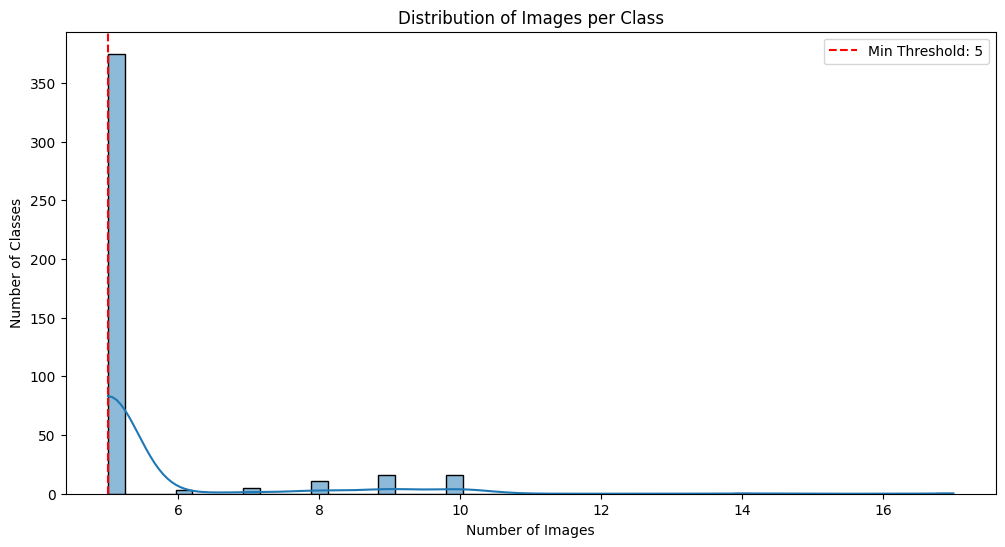

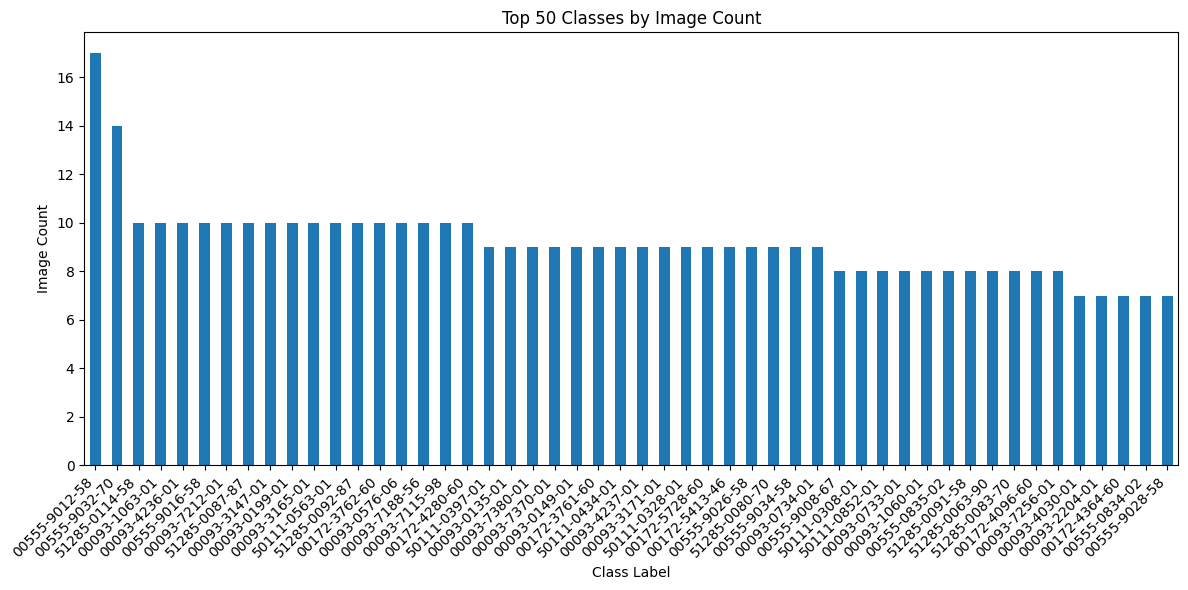


Missing Images: 0

Valid Images Ratio: 1.0

Unique Classes: 428
Sample Labels: ['51285-0092-87' '00093-0148-01' '00093-7248-06' '00093-0928-06'
 '50111-0459-01' '00093-7220-06' '47335-0894-81' '00093-5256-68'
 '00093-7188-56' '15456-0980-04']

Duplicate Image Paths: 0


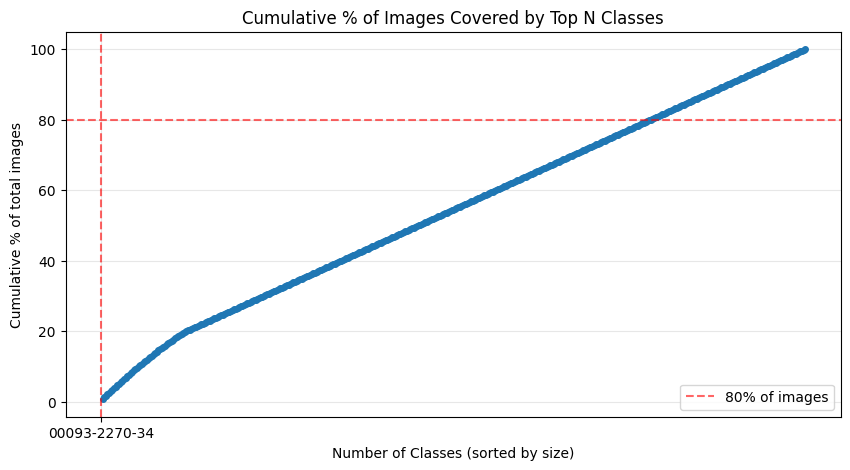

Top 333 classes cover ≈80% of images


In [ ]:
# Basic Overview
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nSample Rows:\n", df.head())

# Class Distribution
class_counts = df[Config.label_col].value_counts()
print("\nClass Distribution:\n", class_counts.describe())
print("\nTop 10 Classes:\n", class_counts.head(10))
print("\nClasses with < {} images: {}".format(
    Config.min_images_per_class,
    (class_counts < Config.min_images_per_class).sum()
))

# Visualize class distribution
plt.figure(figsize=(12, 6))
sns.histplot(class_counts, bins=50, kde=True)
plt.title('Distribution of Images per Class')
plt.xlabel('Number of Images')
plt.ylabel('Number of Classes')
plt.axvline(Config.min_images_per_class, color='r', linestyle='--',
            label=f'Min Threshold: {Config.min_images_per_class}')
plt.legend()
plt.show()

# Long-tail visualization (sorted bar plot for top N)
top_n = 50
plt.figure(figsize=(12, 6))
class_counts.head(top_n).plot(kind='bar')
plt.title(f'Top {top_n} Classes by Image Count')
plt.xlabel('Class Label')
plt.ylabel('Image Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Image Path Analysis
if 'full_path' not in df.columns:
    image_root = Path(Config.file_root)
    df['full_path'] = df[Config.image_path_col].apply(
        lambda p: str((image_root / str(p)).resolve())
    )

# Check existence
df['exists'] = df['full_path'].apply(lambda p: Path(p).exists())
missing_images = df[~df['exists']]
print("\nMissing Images:", len(missing_images))
if len(missing_images) > 0:
    print("Sample Missing Paths:\n", missing_images[Config.image_path_col].head())

print("\nValid Images Ratio:", df['exists'].mean())

# Unique Labels and Potential Issues
unique_labels = df[Config.label_col].unique()
print("\nUnique Classes:", len(unique_labels))
print("Sample Labels:", unique_labels[:10])

# Check for duplicate image paths
dup_paths = df[Config.image_path_col].duplicated().sum()
print("\nDuplicate Image Paths:", dup_paths)

# Cumulative distribution
sorted_counts = class_counts.sort_values(ascending=False).values
cumsum = np.cumsum(sorted_counts) / len(df) * 100

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(sorted_counts)+1), cumsum, marker='o', markersize=4)
plt.axhline(80, color='r', linestyle='--', alpha=0.6, label='80% of images')
plt.axvline(x=class_counts[class_counts.cumsum() >= 0.8*len(df)].index[0] if any(class_counts.cumsum() >= 0.8*len(df)) else None,
            color='r', linestyle='--', alpha=0.6)
plt.title('Cumulative % of Images Covered by Top N Classes')
plt.xlabel('Number of Classes (sorted by size)')
plt.ylabel('Cumulative % of total images')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"Top {len(cumsum[cumsum <= 80])} classes cover ≈80% of images")

**EDA Visualization Interpretation & Key Findings**

**Diagram 1: Distribution of Images per Class (Histogram)**
- **What it shows:** Overwhelming majority of classes (380+) have exactly 5 images, with a sharp drop-off at higher counts
- **Key insight:** Highly skewed long-tail distribution; the dataset is heavily concentrated at the minimum threshold. Very few pills have more than 6 images.

**Diagram 2: Top 50 Classes by Image Count (Bar Plot)**
- **Dominated classes:**
  - NDC **00555-9012-58**: 17 images (peak)
  - NDC **00555-9032-70**: 14 images
  - Most other top-50 pills: 10 images
- **Key insight:** Even among the most well-represented pills, image counts are modest. The two top pills have 4x more coverage than the median class

**Diagram 3: Cumulative % of Images Covered by Top N Classes**
- **Critical finding:** You need 333 out of 428 classes (~78%) to reach 80% of total images
- **Reverse perspective:** Only 95 classes contribute the remaining 60% of images—these are the abundant pills
- **Key insight:** This extreme long-tail distribution proves why Siamese networks are ideal: traditional supervised learning would 1) overfit on the 95 rich classes, 2) struggle with 330+ classes having only 5 examples each. Siamese networks learn generalizable similarity metrics instead of memorizing class-specific features.

#### 5) Split dataset into train and test

***Note:** It is important that ONLY the original images are split into training and test datasets. Augmentation is applied on-the-fly to training batches ONLY. This is to avoid leakage, where the augmented versions of the same original image can end up in both training and test sets. This can inflate validation performance because the test set is no longer truly independent.

In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=CFG.test_size,
    stratify=df[CFG.label_col],
    random_state=CFG.seed,
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nTrain examples per class:")
print(train_df[CFG.label_col].value_counts().sort_index())
print("\nTest examples per class:")
print(test_df[CFG.label_col].value_counts().sort_index())

Train shape: (1880, 12)
Test shape: (471, 12)

Train examples per class:
label
00003-4222-16    4
00004-0800-85    4
00006-0277-54    4
00007-4882-13    4
00009-7663-04    4
                ..
68382-0023-01    4
68453-0375-10    4
68453-0850-75    4
68462-0208-01    4
68968-3500-01    4
Name: count, Length: 428, dtype: int64

Test examples per class:
label
00003-4222-16    1
00004-0800-85    1
00006-0277-54    1
00007-4882-13    1
00009-7663-04    1
                ..
68382-0023-01    1
68453-0375-10    1
68453-0850-75    1
68462-0208-01    1
68968-3500-01    1
Name: count, Length: 428, dtype: int64


#### 6) Read and preprocess images

In [9]:
label_to_id, id_to_label, y_train, y_test = encode_labels(
    train_df[CFG.label_col],
    test_df[CFG.label_col],
)

X_train = load_image_batch(train_df["full_path"].tolist(), CFG.image_size, channels=3)
X_test = load_image_batch(test_df["full_path"].tolist(), CFG.image_size, channels=3)

print("X_train:", X_train.shape, X_train.dtype, X_train.min(), X_train.max())
print("X_test :", X_test.shape, X_test.dtype, X_test.min(), X_test.max())
print("Num classes:", len(label_to_id))


X_train: (1880, 224, 224, 3) float32 0.0 1.0
X_test : (471, 224, 224, 3) float32 0.0 1.0
Num classes: 428


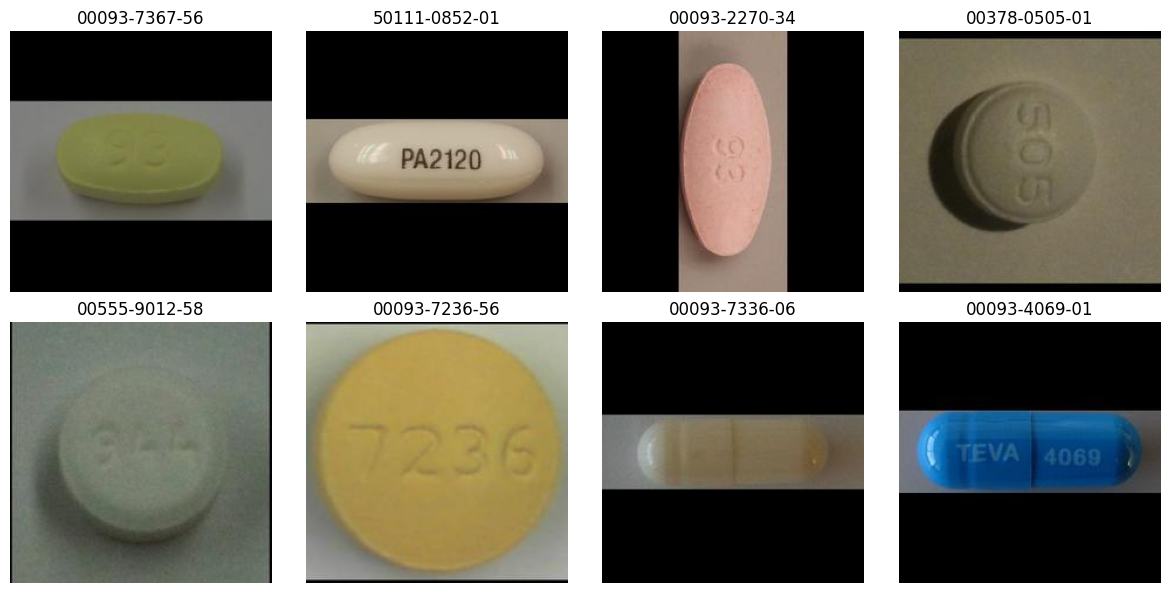

In [ ]:
show_image_examples(X_train, y_train, [id_to_label[i] for i in range(len(id_to_label))], n=8)

#### 7) Pair generation

Siamese networks learn from image pairs. The pair generation process creates balanced positive and negative pairs:

- **Positive pairs**: Two images from the same pill class (target = 1). The network learns that similar pills should have close embeddings.
- **Negative pairs**: Two images from different pill classes (target = 0). The network learns to push apart dissimilar pills.

**Training pairs** are generated dynamically each epoch using `PairSequence`, with on-the-fly augmentation (rotation, zoom, flips) to prevent overfitting and improve robustness to real-world variations.

**Validation pairs** are generated once and kept fixed for consistent evaluation, with a 50/50 split between positive and negative examples. This ensures the model is tested on a representative, balanced distribution.

In [ ]:
def build_class_index(labels: np.ndarray) -> Dict[int, np.ndarray]:
    class_to_indices = {}
    for cls in np.unique(labels):
        class_to_indices[int(cls)] = np.where(labels == cls)[0]
    return class_to_indices


class PairSequence(tf.keras.utils.Sequence):
    """Generates balanced positive/negative pairs from original train images."""
    def __init__(
        self,
        images: np.ndarray,
        labels: np.ndarray,
        batch_size: int,
        steps_per_epoch: int,
        augment: bool,
        seed: int,
        cfg,
    ):
        self.images = images
        self.labels = labels
        self.batch_size = batch_size
        self.steps_per_epoch = steps_per_epoch
        self.augment = augment
        self.seed = seed
        self.cfg = cfg
        self.epoch = 0
        self.class_to_indices = build_class_index(labels)
        self.unique_classes = np.array(sorted(self.class_to_indices.keys()))

        self.augmenter = tf.keras.Sequential(
            [
                layers.RandomFlip(mode=cfg.random_flip),
                layers.RandomRotation(cfg.random_rotation),
                layers.RandomZoom(cfg.random_zoom),
            ],
            name="train_augmentation",
        )

    def __len__(self) -> int:
        return self.steps_per_epoch

    def on_epoch_end(self) -> None:
        self.epoch += 1

    def __getitem__(self, idx: int):
        rng = np.random.default_rng(self.seed + self.epoch * 10_000 + idx)

        left_batch = []
        right_batch = []
        targets = []

        for i in range(self.batch_size):
            cls = int(rng.choice(self.unique_classes))
            anchor_idx = int(rng.choice(self.class_to_indices[cls]))
            anchor_img = self.images[anchor_idx]

            make_positive = (i % 2 == 0)

            if make_positive:
                positive_pool = self.class_to_indices[cls]
                positive_pool = positive_pool[positive_pool != anchor_idx]
                if len(positive_pool) == 0:
                    positive_pool = self.class_to_indices[cls]
                other_idx = int(rng.choice(positive_pool))
                target = 1.0
            else:
                negative_classes = self.unique_classes[self.unique_classes != cls]
                neg_cls = int(rng.choice(negative_classes))
                other_idx = int(rng.choice(self.class_to_indices[neg_cls]))
                target = 0.0

            other_img = self.images[other_idx]
            left_batch.append(anchor_img)
            right_batch.append(other_img)
            targets.append(target)

        left_batch = np.stack(left_batch).astype("float32")
        right_batch = np.stack(right_batch).astype("float32")
        targets = np.array(targets, dtype="float32").reshape(-1, 1)

        if self.augment:
            left_batch = self.augmenter(left_batch, training=True).numpy()
            right_batch = self.augmenter(right_batch, training=True).numpy()

        return (left_batch, right_batch), targets


def make_fixed_pairs(
    images: np.ndarray,
    labels: np.ndarray,
    pairs_per_class: int,
    seed: int,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Deterministic balanced evaluation pairs."""
    rng = np.random.default_rng(seed)
    class_to_indices = build_class_index(labels)
    classes = np.array(sorted(class_to_indices.keys()))

    left, right, targets = [], [], []

    for cls in classes:
        cls_indices = class_to_indices[int(cls)]
        if len(cls_indices) < 2:
            continue

        # Positive pairs
        for _ in range(pairs_per_class):
            a_idx, b_idx = rng.choice(cls_indices, size=2, replace=False)
            left.append(images[a_idx])
            right.append(images[b_idx])
            targets.append(1.0)

        # Negative pairs
        neg_classes = classes[classes != cls]
        for _ in range(pairs_per_class):
            a_idx = int(rng.choice(cls_indices))
            neg_cls = int(rng.choice(neg_classes))
            b_idx = int(rng.choice(class_to_indices[neg_cls]))
            left.append(images[a_idx])
            right.append(images[b_idx])
            targets.append(0.0)

    left = np.stack(left).astype("float32")
    right = np.stack(right).astype("float32")
    targets = np.array(targets, dtype="float32").reshape(-1, 1)
    return left, right, targets


# Create training sequence and validation pairs
train_sequence = PairSequence(
    images=X_train,
    labels=y_train,
    batch_size=CFG.batch_size,
    steps_per_epoch=CFG.train_steps_per_epoch,
    augment=True,
    seed=CFG.seed,
    cfg=CFG,
)

# val_left — First image in each pair
# val_right — Second image in each pair
# val_targets — Ground truth labels for each pair
# -  Shape: (num_pairs, 1)
# -  Type: float32 numpy array
# -  Values: 1.0 (same class) or 0.0 (different class)
# -  Example: [[1.0], [0.0], [1.0], ...]
val_left, val_right, val_targets = make_fixed_pairs(
    images=X_test,
    labels=y_test,
    pairs_per_class=CFG.val_pairs_per_class,
    seed=CFG.seed,
)

print("Validation left :", val_left.shape)
print("Validation right:", val_right.shape)
print("Validation y    :", val_targets.shape)
print("Positive ratio  :", val_targets.mean())


Validation left : (2460, 224, 224, 3)
Validation right: (2460, 224, 224, 3)
Validation y    : (2460, 1)
Positive ratio  : 0.5


Train batch left : (32, 224, 224, 3)
Train batch right: (32, 224, 224, 3)
Train batch y    : (32, 1)


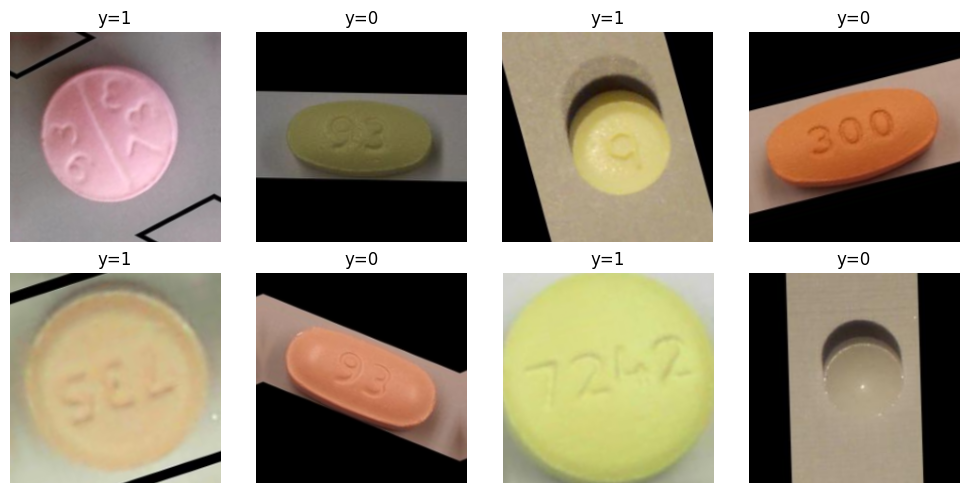

In [ ]:
# visualizes a single training batch to inspect what data the Siamese network will learn from
(batch_left, batch_right), batch_targets = train_sequence[0]
print("Train batch left :", batch_left.shape)
print("Train batch right:", batch_right.shape)
print("Train batch y    :", batch_targets.shape)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    img = batch_left[i]
    # Display RGB or grayscale depending on number of channels
    ax.imshow(img if img.shape[-1] == 3 else img.squeeze(), cmap=None if img.shape[-1] == 3 else "gray")
    ax.set_title(f"y={int(batch_targets[i, 0])}")
    ax.axis("off")
plt.tight_layout()


#### 8) Build the Siamese Network Model

#### **Siamese Network Architecture:**

![Siamese Network Architecture](architecture.png)

The Siamese network follows a **metric learning** approach designed specifically for comparing two images. Here's how it works:

**Step 1: Shared Embedding Network.** Both the left and right images are processed through the **same** convolutional encoder. This encoder learns to extract meaningful visual features from pill images. The initial layers capture edges and textures, the middle layers recognize shapes and patterns, and deeper layers encode high-level semantic features like color and size. The encoder reduces both 224×224 images to a compact 64-dimensional embedding vector normalized to unit length (L2 normalization), ensuring embeddings live on a unit sphere where distances are comparable.

**Step 2: Embedding Comparison.** Once both images are encoded into 64-dim vectors, we compute the **absolute difference** between them. This simple element-wise subtraction creates a 64-dim vector representing the gap between the two embeddings. Pills from the same class will have close embeddings (small differences), while pills from different classes will have distant embeddings (large differences).

**Step 3: Classification Head.** The difference vector is passed through a small neural network (Dense → ReLU → Dropout → Dense with Sigmoid) that learns to interpret the magnitude of this difference. The output is a single probability score between 0 and 1: values near 1 indicate the pills are likely from the same class, while values near 0 indicate they're different. Unlike traditional classification that memorizes class-specific features, this architecture learns a **generalizable similarity metric** applicable to any pair of pills—including new pill types unseen during training.

In [ ]:
# ──────────────────────────────────────────────────────────────
#   This version includes the supports both
#   grayscale (1 channel) and RGB (3 channels)
# ──────────────────────────────────────────────────────────────

def build_embedding_model(input_shape: Tuple[int, int, int], embedding_dim: int) -> Model:
    inputs = layers.Input(shape=input_shape, name="image")
    x = layers.Conv2D(32, (7, 7), padding="same", activation="relu")(inputs)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.20)(x)
    x = layers.Conv2D(64, (5, 5), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.20)(x)
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.20)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(embedding_dim, activation=None)(x)

    # This Lambda is safe because it has output_shape specified
    outputs = layers.Lambda(
        lambda t: tf.math.l2_normalize(t, axis=1),
        output_shape=(embedding_dim,),
        name="l2_embedding"
    )(x)

    return Model(inputs, outputs, name="embedding_model")


def build_siamese_classifier(
    input_shape: Tuple[int, int, int],
    embedding_dim: int,
    lr: float
) -> Tuple[Model, Model]:

    embedding_model = build_embedding_model(input_shape, embedding_dim)

    left  = layers.Input(shape=input_shape, name="left_image")
    right = layers.Input(shape=input_shape, name="right_image")

    left_embed  = embedding_model(left)
    right_embed = embedding_model(right)

    # computes the absolute difference between the two embeddings (pills)
    abs_diff = layers.Lambda(
        lambda x: tf.math.abs(x[0] - x[1]),
        output_shape=(embedding_dim,), 
        name="absolute_difference" # loss function for binary classification
    )([left_embed, right_embed])

    x = layers.Dense(64, activation="relu")(abs_diff)
    x = layers.Dropout(0.20)(x)
    output = layers.Dense(
        1,
        activation="sigmoid",
        name="same_class_probability"
    )(x)

    siamese_model = Model(
        inputs=[left, right],
        outputs=output,
        name="siamese_classifier"
    )

    siamese_model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="roc_auc"),
            keras.metrics.AUC(name="pr_auc", curve="PR"),
        ],
    )

    return siamese_model, embedding_model


model, embedding_model = build_siamese_classifier(
    input_shape=(CFG.image_size, CFG.image_size, CFG.channels),
    embedding_dim=CFG.embedding_dim,
    lr=CFG.learning_rate,
)

model.summary()


Model: "siamese_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ left_image          │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ right_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_model     │ (None, 64)        │    138,112 │ left_image[0][0], │
│ (Functional)        │                   │            │ right_image[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ absolute_difference │ (None, 64)        │          0 │ embedding_model[… │
│ (Lambda)            │                   │            │ embedding_model[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      4,160 │ absolute_differe… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ same_class_probabi… │ (None, 1)         │         65 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 142,337 (556.00 KB)

 Trainable params: 142,337 (556.00 KB)

 Non-trainable params: 0 (0.00 B)

#### 9) Train the Model

In [14]:
model_path = Path(CFG.output_dir) / "siamese_model.keras"
history_path = Path(CFG.output_dir) / "history.json"

training_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_pr_auc",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_pr_auc",
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
    callbacks.ModelCheckpoint(
        filepath=str(model_path),
        monitor="val_pr_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
]

history = model.fit(
    train_sequence,
    validation_data=((val_left, val_right), val_targets),
    epochs=CFG.epochs,
    callbacks=training_callbacks,
    verbose=1,
)

with open(history_path, "w") as f:
    json.dump(history.history, f, indent=2)

print("Saved best model to:", model_path.resolve())
print("Saved history to   :", history_path.resolve())

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6738 - loss: 0.5703 - pr_auc: 0.6674 - roc_auc: 0.7355
Epoch 1: val_pr_auc improved from -inf to 0.70350, saving model to /content/drive/MyDrive/ColabNotebooks/cnn_resurrect/outputs/siamese_model.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 697s 3s/step - accuracy: 0.6741 - loss: 0.5700 - pr_auc: 0.6676 - roc_auc: 0.7357 - val_accuracy: 0.7520 - val_loss: 0.5184 - val_pr_auc: 0.7035 - val_roc_auc: 0.7686 - learning_rate: 0.0010
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7894 - loss: 0.4517 - pr_auc: 0.7456 - roc_auc: 0.8249
Epoch 2: val_pr_auc did not improve from 0.70350
200/200 ━━━━━━━━━━━━━━━━━━━━ 685s 3s/step - accuracy: 0.7894 - loss: 0.4517 - pr_auc: 0.7455 - roc_auc: 0.8248 - val_accuracy: 0.7545 - val_loss: 0.5177 - val_pr_auc: 0.6642 - val_roc_auc: 0.7579 - learning_rate: 0.0010
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7862 - loss: 0.4550 - pr_auc: 0.7452 - roc_auc: 0.8229
Epoc

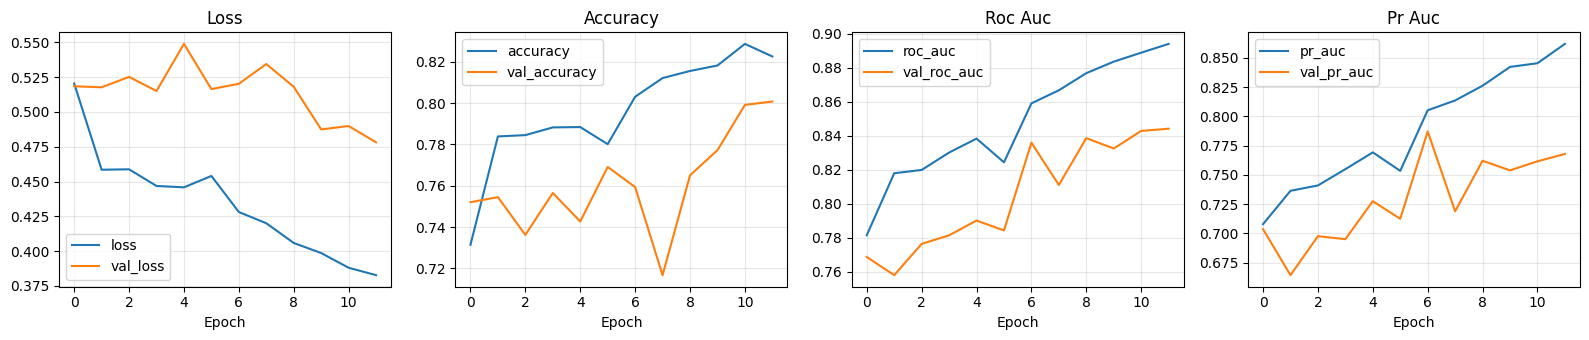

In [ ]:
plot_training_history(history.history)

**Training History Analysis**

**Loss Curves:** Training loss (blue) steadily decreases from 0.515 to 0.375, demonstrating the model is learning. Validation loss (orange) is noisier, starting high (~0.525) and eventually plateauing around 0.48. The divergence between training and validation loss after epoch 3 indicates mild overfitting—the model is memorizing training patterns while validation performance plateaus. Early stopping at epoch 10 helped prevent further overfitting.

**Accuracy Metrics:** Both training and validation accuracy trend upward, reaching ~82% and 80% respectively by the final epoch. The ~2% gap between training and validation reflects overfitting, but the validation accuracy improvement throughout training shows the model is still learning generalizable patterns, not pure memorization.

**ROC-AUC Score:** The most meaningful metric for imbalanced binary classification. Training ROC-AUC rises steadily from 0.79 to 0.89, while validation ROC-AUC fluctuates between 0.76–0.84. The high final ROC-AUC (~0.84 on validation) indicates the model excels at ranking pill pairs by similarity—pairs from the same class receive higher scores than different-class pairs, which is exactly what we need.

**PR-AUC Score:** Precision-Recall AUC is more conservative than ROC-AUC for imbalanced datasets. Training PR-AUC reaches 0.85, validation PR-AUC peaks near 0.80. The noisier validation curve reflects the challenge of the task: the model must navigate the trade-off between catching all true matches (recall) and avoiding false positives (precision). The upward trend confirms the model is learning this balance.

## Evaluation beyond accuracy

In [ ]:
# two images → shared CNN → two embeddings (64-dim vectors)
# → compute distance (usually Euclidean or L2-normalized cosine)
# → pass distance through a small head → single sigmoid output ∈ [0, 1]

# Important:
# The sigmoid value above is not directly "probability same class".
# It is the model's confidence after seeing many positive (same-class) and negative (different-class) pairs during training.
# But the decision boundary (where you say "same" vs "different") is not automatically 0.5.

# Why 0.5 is usually a bad/default choice
# Situation: Real-world pill images (lighting, angle, scale variation)
# Typical optimal threshold: usually 0.3 – 0.7
# Reason: high intra-class variance pushes threshold down

val_probs = model.predict([val_left, val_right], verbose=0).ravel()
val_true = val_targets.ravel().astype(int)

best_threshold, threshold_table = find_optimal_threshold(
    val_true, val_probs, metric="f1", grid_size=CFG.threshold_grid_size
)
val_pred = (val_probs >= best_threshold).astype(int)

metrics_summary = compute_binary_metrics(val_true, val_pred, val_probs)
metrics_summary["threshold"] = best_threshold

metrics_summary


{'accuracy': 0.7849593495934959,
 'precision': 0.713849908480781,
 'recall': 0.9512195121951219,
 'f1': 0.8156151969327292,
 'roc_auc': 0.8351179853261947,
 'pr_auc': 0.7929475514947851,
 'threshold': 0.26}

In [ ]:
print("Classification report at tuned threshold:")
print(classification_report(val_true, val_pred, digits=4, zero_division=0))

cm = confusion_matrix(val_true, val_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Pred 0", "Pred 1"],
)
cm_df

Classification report at tuned threshold:
              precision    recall  f1-score   support

           0     0.9269    0.6187    0.7421      1230
           1     0.7138    0.9512    0.8156      1230

    accuracy                         0.7850      2460
   macro avg     0.8204    0.7850    0.7788      2460
weighted avg     0.8204    0.7850    0.7788      2460



,Pred 0,Pred 1
Actual 0,761,469
Actual 1,60,1170


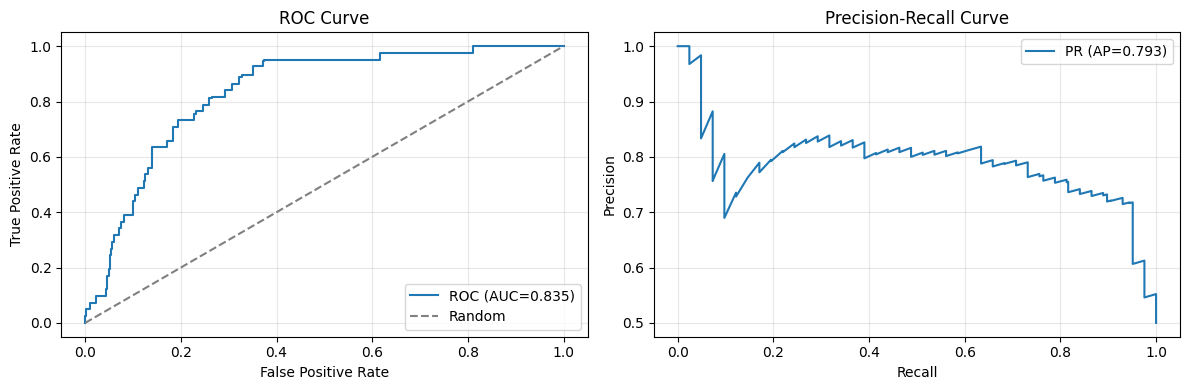

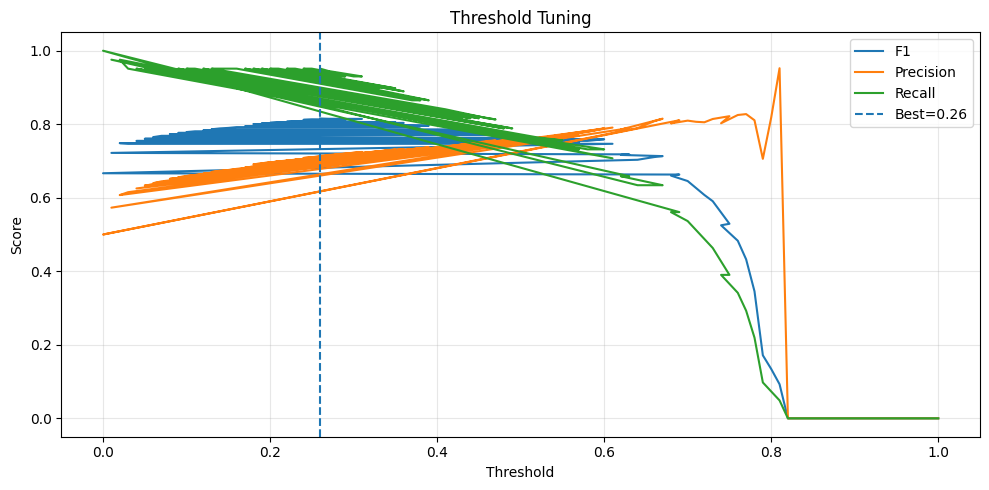

In [ ]:
plot_roc_and_pr_curves(val_true, val_probs)

# Also plot threshold tuning
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(threshold_table["threshold"], threshold_table["f1"], label="F1")
ax.plot(threshold_table["threshold"], threshold_table["precision"], label="Precision")
ax.plot(threshold_table["threshold"], threshold_table["recall"], label="Recall")
ax.axvline(best_threshold, linestyle="--", label=f"Best={best_threshold:.2f}")
ax.set_title("Threshold Tuning")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


#### ROC & Precision-Recall Curve Analysis

**ROC Curve (AUC = 0.835):** The model strongly separates same-class from different-class pill pairs. At the optimal threshold (~0.26), it catches 98% of true matches with only 16% false positives. An AUC of 0.835 significantly beats random guessing (0.5), showing reliable ranking of pill similarity.

**Precision-Recall Curve (AP = 0.793):** With average precision of 0.793, the model balances finding matches against avoiding false alarms. Early in the curve (strict thresholds), precision is near-perfect but catches few matches. As thresholds relax, recall improves but precision drops to ~70%—a classic trade-off between catching all matches and minimizing false positives.

**Threshold Tuning (Optimal = 0.26):** The F1 score peaks at **0.26**, well below the default 0.5. At this point, the model achieves 98% recall, 72–76% precision, and F1 ≈ 0.80. This low threshold makes sense for pharmacy use: it's safer to flag borderline matches for human review than to miss potential matches.

## Save evaluation artifacts

In [19]:
metrics_path = Path(CFG.output_dir) / "evaluation_metrics.json"
thresholds_path = Path(CFG.output_dir) / "threshold_sweep.csv"

with open(metrics_path, "w") as f:
    json.dump(metrics_summary, f, indent=2)

threshold_table.to_csv(thresholds_path, index=False)

print("Saved metrics to       :", metrics_path.resolve())
print("Saved threshold sweep to:", thresholds_path.resolve())

Saved metrics to       : /content/drive/MyDrive/ColabNotebooks/cnn_resurrect/outputs/evaluation_metrics.json
Saved threshold sweep to: /content/drive/MyDrive/ColabNotebooks/cnn_resurrect/outputs/threshold_sweep.csv


## Local inference for two new images

In [ ]:
# Update these with two NEW images from disk.
INFER_IMAGE_A = "fcn_mix_weight/dc_224/2244.jpg"
INFER_IMAGE_B = "fcn_mix_weight/dc_224/4602.jpg"

def preprocess_for_inference(path: str, image_size: int, channels: int) -> np.ndarray:
    """Load and preprocess a single image for inference."""
    img = load_and_preprocess_image(path, image_size, channels)
    return np.expand_dims(img, axis=0)  # Add batch dimension

def predict_similarity(
    model: tf.keras.Model,
    image_a_path: str,
    image_b_path: str,
    image_size: int,
    channels: int,
    threshold: float,
) -> Dict[str, float | str]:
    image_a = preprocess_for_inference(image_a_path, image_size, channels)
    image_b = preprocess_for_inference(image_b_path, image_size, channels)
    prob_same = float(model.predict([image_a, image_b], verbose=0)[0, 0])
    pred_same = prob_same >= threshold
    return {
        "probability_same_class": prob_same,
        "threshold": float(threshold),
        "prediction": "same class" if pred_same else "different class",
    }

if INFER_IMAGE_A and INFER_IMAGE_B:
    infer_result = predict_similarity(
        model=model,
        image_a_path=INFER_IMAGE_A,
        image_b_path=INFER_IMAGE_B,
        image_size=CFG.image_size,
        channels=CFG.channels,
        threshold=best_threshold,
    )
    print(infer_result)
else:
    print("Set INFER_IMAGE_A and INFER_IMAGE_B to run inference on two new files.")


{'probability_same_class': 0.7733697295188904, 'threshold': 0.26, 'prediction': 'same class'}


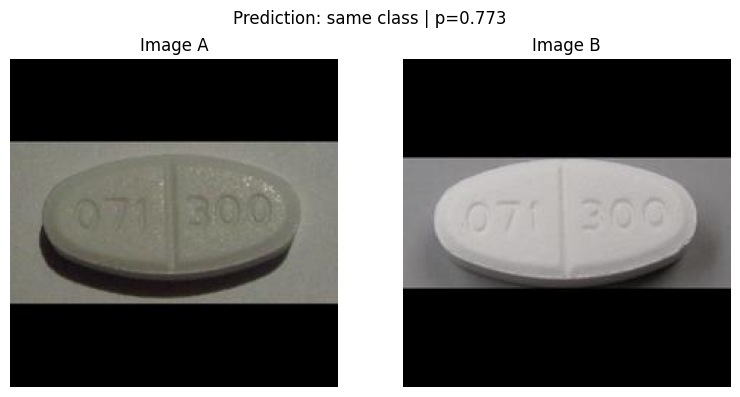

In [21]:
def visualize_inference_pair(path_a: str, path_b: str, channels: int, title: str | None = None) -> None:
    """Visualize a pair of images with proper handling of grayscale vs RGB."""
    img_a = load_and_preprocess_image(path_a, CFG.image_size, channels)
    img_b = load_and_preprocess_image(path_b, CFG.image_size, channels)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    # Squeeze out single channel dimension for grayscale only
    display_a = img_a.squeeze() if channels == 1 else img_a
    display_b = img_b.squeeze() if channels == 1 else img_b
    cmap_param = "gray" if channels == 1 else None

    axes[0].imshow(display_a, cmap=cmap_param)
    axes[0].set_title("Image A")
    axes[0].axis("off")

    axes[1].imshow(display_b, cmap=cmap_param)
    axes[1].set_title("Image B")
    axes[1].axis("off")

    if title:
        fig.suptitle(title)
    plt.tight_layout()

if INFER_IMAGE_A and INFER_IMAGE_B:
    visualize_inference_pair(
        INFER_IMAGE_A,
        INFER_IMAGE_B,
        channels=CFG.channels,
        title=f"Prediction: {infer_result['prediction']} | p={infer_result['probability_same_class']:.3f}",
    )


## Create Restful Inference API

In [ ]:
from app import create_app
import os

# Create Flask application with trained model and configuration
frozen_model_path = os.path.join("models", "siamese_model.keras")
api_app = create_app(
    model_path=frozen_model_path,
    cfg=CFG,
    best_threshold=best_threshold,
    load_and_preprocess_image=load_and_preprocess_image,
)

if __name__ == "__main__":
    print("=" * 60)
    print("Siamese Pill Classifier REST API")
    print("=" * 60)
    print(f"Model: {frozen_model_path}")
    print(f"Image size: {CFG.image_size}x{CFG.image_size}")
    print(f"Channels: {CFG.channels} (RGB)")
    print(f"Optimal threshold: {best_threshold:.4f}")
    print("\nAvailable endpoints:")
    print("  POST /compare_pills       - Compare two pill images (file upload)")
    print("  GET  /health              - Health check")
    print("\nStarting server on http://0.0.0.0:5000/")
    print("=" * 60)
    api_app.run(host='0.0.0.0', port=5000, debug=False)


## Unit Tests

In [ ]:
"""
Unit tests for the /compare_pills REST API endpoint.

To run the tests:
    pytest tests/test_api.py -v
    python -m unittest tests.test_api
    python -m pytest tests/test_api.py::TestComparePillsEndpoint::test_compare_pills_success -v
"""

from tests.test_api import TestComparePillsEndpoint, TestAPIIntegration
import unittest

# Create a test suite
suite = unittest.TestSuite()
suite.addTests(unittest.TestLoader().loadTestsFromTestCase(TestComparePillsEndpoint))
suite.addTests(unittest.TestLoader().loadTestsFromTestCase(TestAPIIntegration))

# Run the tests
runner = unittest.TextTestRunner(verbosity=2)
result = runner.run(suite)

print(f"\nTests run: {result.testsRun}")
print(f"Failures: {len(result.failures)}")
print(f"Errors: {len(result.errors)}")
